# Grid2D Theorem Figure

This notebook plots the 2D perturbation geometry generated by `run_grid2d.py`. It combines the QFIM ellipse/contour view and the approximation-ratio heat map into one two-panel figure.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("data/grid2d")
FIGURE_DIR = Path("paper_figures")
FIGURE_DIR.mkdir(exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 220,
    "font.size": 30,
    "axes.labelsize": 33,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 26,
    "axes.titlesize": 33,
})

def load_config(dataset_dir):
    with open(dataset_dir / "config.json") as f:
        return json.load(f)

def choose_dataset(data_dir, experiment_name="grid2d"):
    candidates = []
    for dataset_dir in sorted(data_dir.iterdir()) if data_dir.exists() else []:
        if not (dataset_dir / "config.json").exists() or not (dataset_dir / "results.npz").exists():
            continue
        config = load_config(dataset_dir)
        if config.get("experiment_name") != experiment_name:
            continue
        candidates.append(("__smoke" in dataset_dir.name, dataset_dir.stat().st_mtime, dataset_dir.name, dataset_dir, config))
    if not candidates:
        raise FileNotFoundError(f"No {experiment_name} dataset found in {data_dir}. Run python run_grid2d.py first.")
    candidates.sort(key=lambda item: (item[0], -item[1]))
    _, _, name, dataset_dir, config = candidates[0]
    results = np.load(dataset_dir / "results.npz", allow_pickle=False)
    return name, config, results

In [2]:
grid_dataset, grid_config, grid_data = choose_dataset(DATA_DIR)

print("dataset =", grid_dataset)
print("experiment =", grid_config["experiment_name"])
print("N =", grid_config["n"])
print("time =", grid_config["time"])
print("delta indices =", grid_config["delta_indices"])
print("QFIM =")
print(grid_data["qfim"])

dataset = ising1d__tfim__xfield-zfield__plus__grid2d__N10
experiment = grid2d
N = 10
time = 1.0
delta indices = {'delta_0': 'xfield', 'delta_1': 'zfield'}
QFIM =
[[2.2114487e+01 1.6607573e-06]
 [1.6607573e-06 6.1940041e+01]]


## Combined Figure

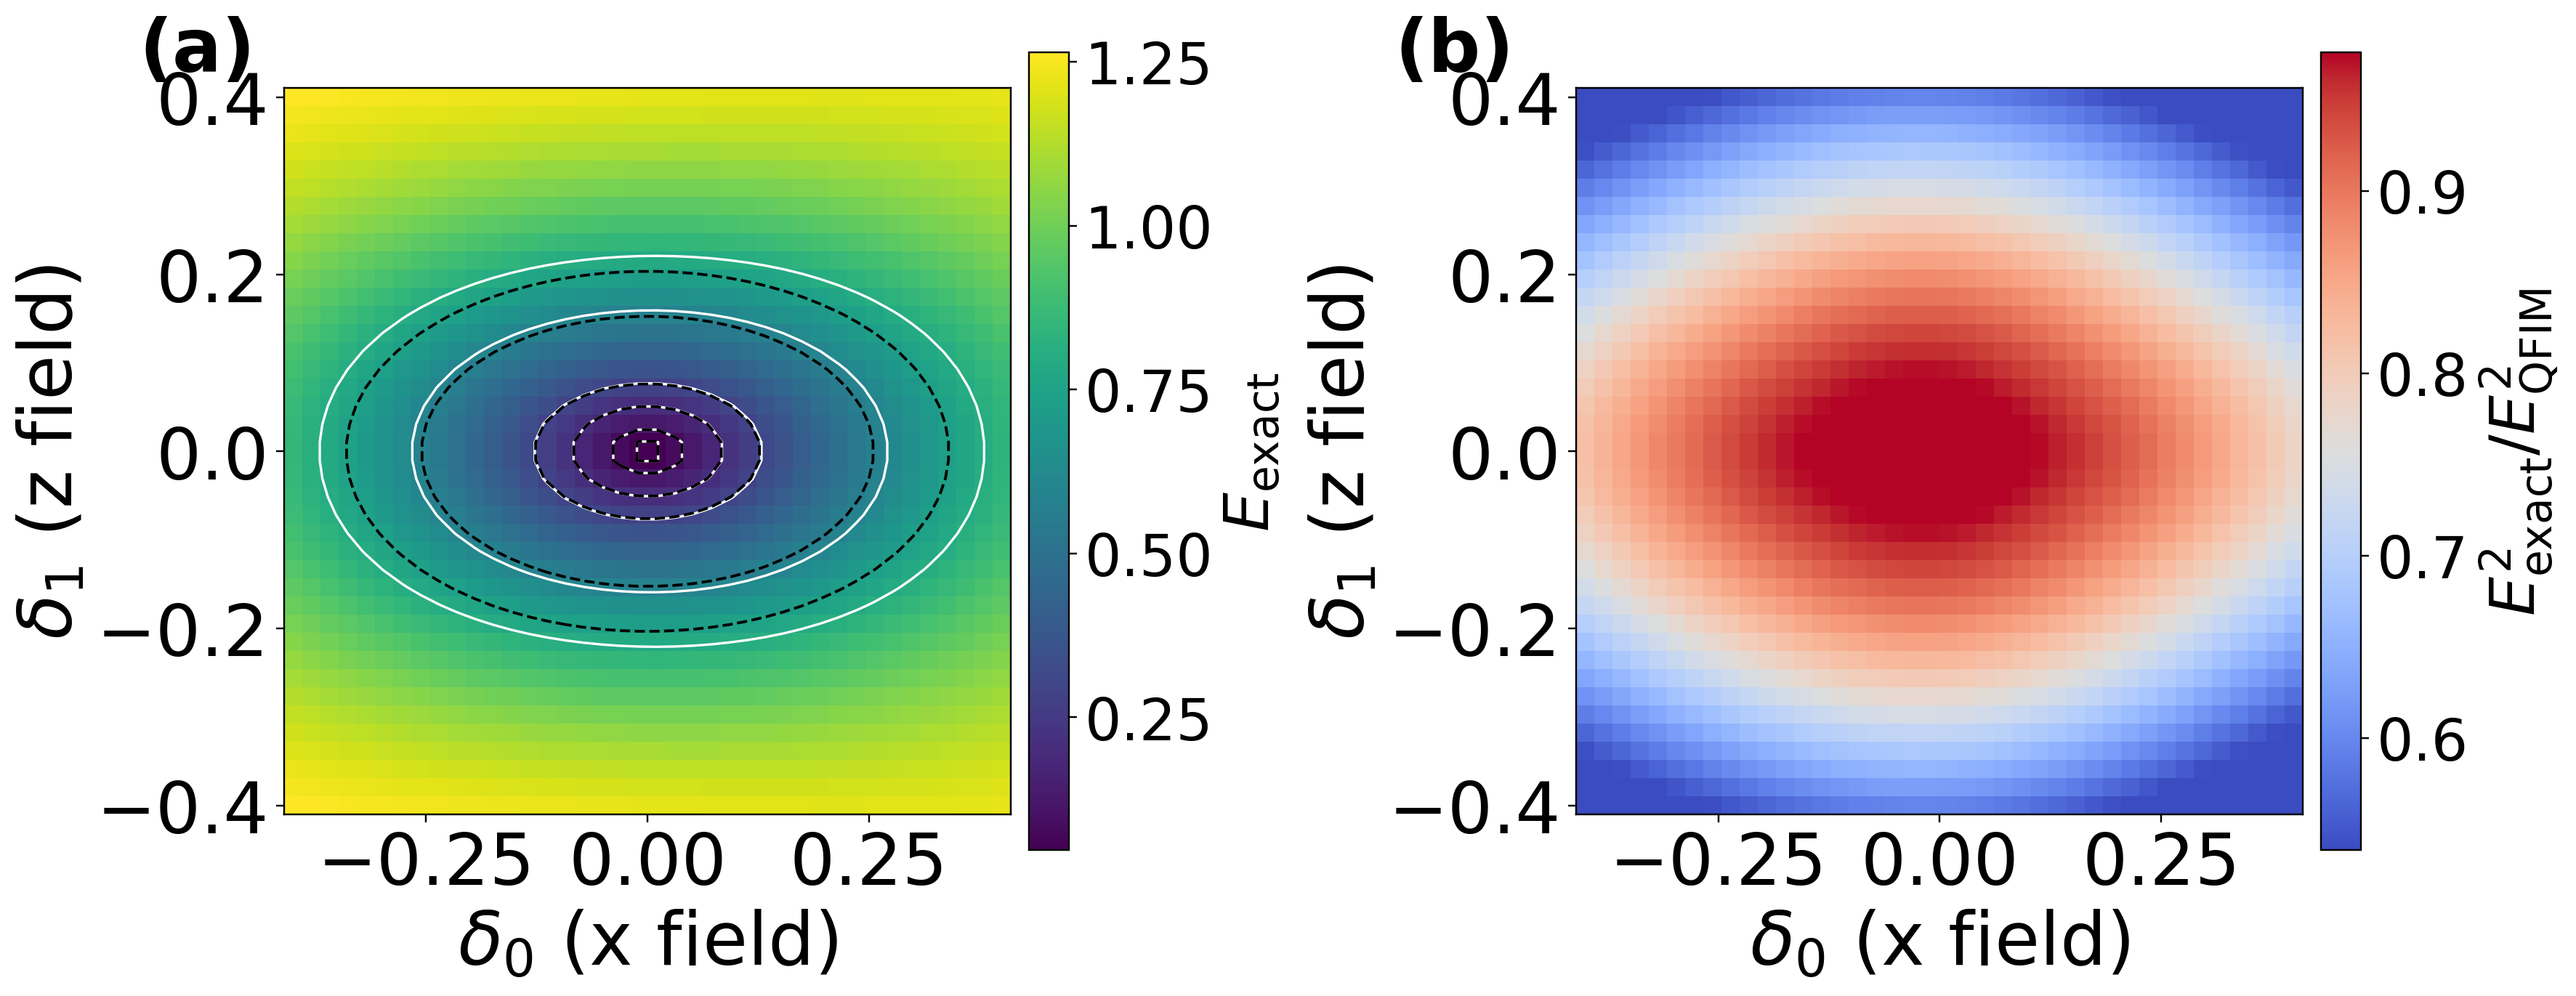

In [3]:
delta_0 = grid_data["delta_0_values"]
delta_1 = grid_data["delta_1_values"]
exact = grid_data["exact_error_grid"]
qfi = grid_data["qfi_error_grid"]
ratio = grid_data["ratio_grid"]
ratio_plot = np.ma.masked_invalid(ratio)

levels = [0.05, 0.10, 0.20, 0.30, 0.60, 0.80]
levels = [level for level in levels if level < np.nanmax(exact)]

vmin, vmax = np.nanpercentile(ratio, [5, 95])
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin, vmax = np.nanmin(ratio), np.nanmax(ratio)

fig, axes = plt.subplots(1, 2, figsize=(16.0, 6.5), constrained_layout=True)

ax = axes[0]
mesh0 = ax.pcolormesh(delta_0, delta_1, exact, shading="auto", cmap="viridis")
cbar0 = fig.colorbar(mesh0, ax=ax, label=r"$E_{\mathrm{exact}}$", shrink=0.82, pad=0.025)
cbar0.ax.tick_params(labelsize=26)
cbar0.set_label(r"$E_{\mathrm{exact}}$", fontsize=28)
if levels:
    ax.contour(delta_0, delta_1, exact, levels=levels, colors="white", linewidths=1.1)
    ax.contour(delta_0, delta_1, qfi, levels=levels, colors="black", linewidths=1.25, linestyles="--")
ax.set_xlabel(r"$\delta_0$ (x field)")
ax.set_ylabel(r"$\delta_1$ (z field)")
ax.set_aspect("equal", adjustable="box")
ax.tick_params(axis="both", which="major", labelsize=32)
ax.text(-0.20, 1.1, "(a)", transform=ax.transAxes, ha="left", va="top", fontsize=33, fontweight="bold", clip_on=False)

ax = axes[1]
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad("lightgray")
mesh1 = ax.pcolormesh(delta_0, delta_1, ratio_plot, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
cbar1 = fig.colorbar(mesh1, ax=ax, label=r"$E_{\mathrm{exact}}^2/E_{\mathrm{QFIM}}^2$", shrink=0.82, pad=0.025)
cbar1.ax.tick_params(labelsize=26)
cbar1.set_label(r"$E_{\mathrm{exact}}^2/E_{\mathrm{QFIM}}^2$", fontsize=28)
ax.set_xlabel(r"$\delta_0$ (x field)")
ax.set_ylabel(r"$\delta_1$ (z field)")
ax.set_aspect("equal", adjustable="box")
ax.tick_params(axis="both", which="major", labelsize=32)
ax.text(-0.25, 1.1, "(b)", transform=ax.transAxes, ha="left", va="top", fontsize=33, fontweight="bold", clip_on=False)

fig.savefig(FIGURE_DIR / "grid2d_theorem.pdf", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "grid2d_theorem.png", bbox_inches="tight")
plt.show()